# California House Price Predictor

This notebook documents a reproducible linear-regression workflow using the California Housing dataset. The target is median house value in $100,000s (1990 USD).

In [14]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACTS, REPORTS = ROOT / 'artifacts', ROOT / 'reports'
ARTIFACTS.mkdir(exist_ok=True); REPORTS.mkdir(exist_ok=True)
plt.style.use('ggplot')

## Load and explore the data

Invalid strings and empty values are safely converted to missing values. Median imputation is fitted only on the training data later in the pipeline.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


,missing_values
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


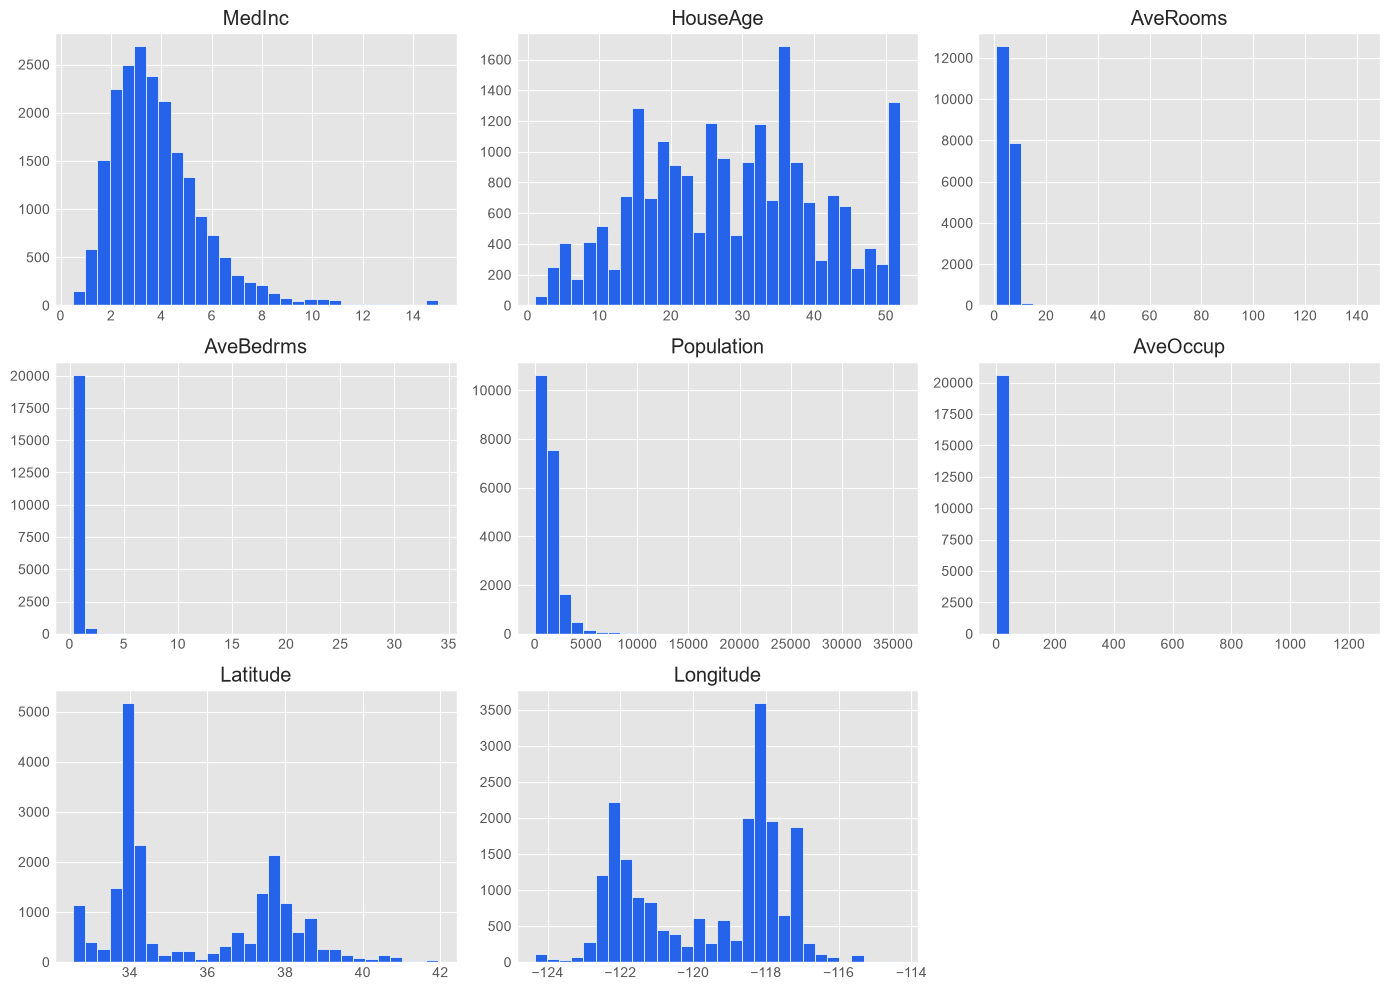

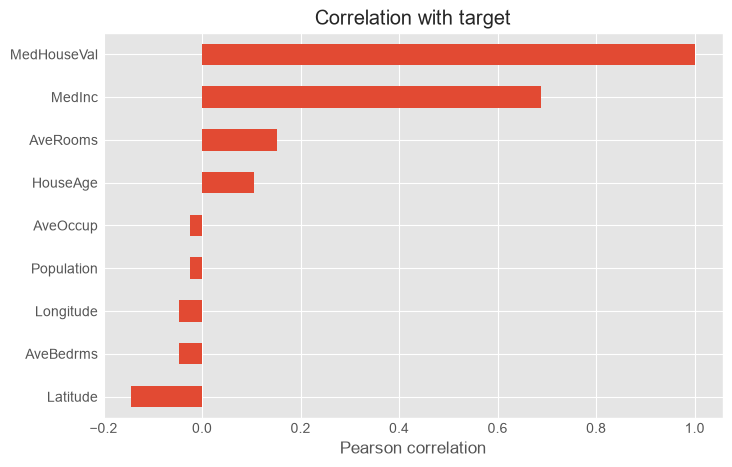

In [15]:
features, target = fetch_california_housing(as_frame=True, return_X_y=True)
X = pd.DataFrame(features).apply(pd.to_numeric, errors='coerce')
y = pd.Series(pd.to_numeric(target, errors='coerce'), name='MedHouseVal')
data = pd.concat([X, y], axis=1)

display(data.head())
display(data.describe().T)
display(data.isna().sum().rename('missing_values').to_frame())

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, column in zip(axes.flat, data.columns):
    values = data.loc[:, [column]].iloc[:, 0].dropna().to_numpy()
    ax.hist(values, bins=30, color='#2563eb', edgecolor='white')
    ax.set_title(column)
axes.flat[-1].set_visible(False)
fig.tight_layout()
plt.show()

data.corr(numeric_only=True)['MedHouseVal'].sort_values().plot.barh(figsize=(8, 5), title='Correlation with target')
plt.xlabel('Pearson correlation')
plt.show()

## Train and evaluate

An 80/20 held-out split is used to evaluate the baseline. The saved pipeline contains both preprocessing and the fitted model.

,value
MAE ($100k),0.5332
RMSE ($100k),0.7456
R²,0.5758


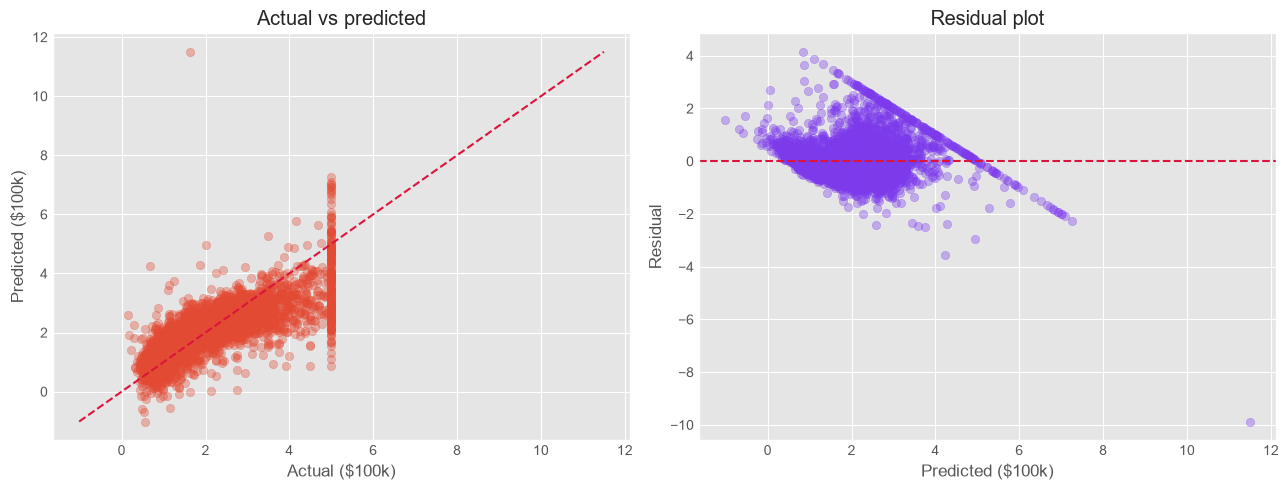

109

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression()),
])
model.fit(X_train, y_train)
predictions = pd.Series(model.predict(X_test), index=y_test.index, name='predicted')

metrics = {
    'MAE ($100k)': mean_absolute_error(y_test, predictions),
    'RMSE ($100k)': mean_squared_error(y_test, predictions) ** 0.5,
    'R²': r2_score(y_test, predictions),
}
display(pd.Series(metrics).round(4).to_frame('value'))

results = pd.DataFrame({'actual': y_test, 'predicted': predictions})
results['residual'] = results.actual - results.predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(results.actual, results.predicted, alpha=.35)
limits = [min(results.actual.min(), results.predicted.min()), max(results.actual.max(), results.predicted.max())]
axes[0].plot(limits, limits, '--', color='crimson')
axes[0].set(xlabel='Actual ($100k)', ylabel='Predicted ($100k)', title='Actual vs predicted')
axes[1].scatter(results.predicted, results.residual, alpha=.35, color='#7c3aed')
axes[1].axhline(0, linestyle='--', color='crimson')
axes[1].set(xlabel='Predicted ($100k)', ylabel='Residual', title='Residual plot')
fig.tight_layout()
plt.show()

joblib.dump(model, ARTIFACTS / 'california_housing_linear_regression.joblib')
(REPORTS / 'notebook_metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')

## Conclusion

Linear regression is an interpretable baseline. For a stronger project, compare regularized linear models and tree ensembles with cross-validation. This historical, block-group dataset must not be used for real property valuations.